# BrainBoard — Ensemble Classifier for EEG Motor Imagery

**Cel:** porównanie pojedynczych klasyfikatorów i zbudowanie ensemble (voting + stacking), który łączy ich predykcje, by zmaksymalizować accuracy.

| Etap | Zawartość |
|------|-----------|
| 1 | Ładowanie danych (10–15 subjectów, pasmo 8–30 Hz) |
| 2 | Ekstrakcja cech: CSP, Band Power, Combined |
| 3 | Baseline — 8 pojedynczych modeli × 3 zestawy cech |
| 4 | **Voting Ensemble** — soft (ważone prob.) + hard (majority vote) |
| 5 | **Stacking Ensemble** — meta-learner (Logistic Regression) |
| 6 | Finalne porównanie + macierze pomyłek |

> Dane: PhysioNet EEG Motor Movement/Imagery Dataset (Schalk et al., 2004)  
> Framework: `scikit-learn` + `mne`

## Krok 1 — Instalacja zależności

Instaluje biblioteki potrzebne do analizy EEG i trenowania modeli: `mne` do przetwarzania sygnałów, `scikit-learn` do klasyfikacji i budowy ensemble, `kagglehub` do pobrania datasetu. Wystarczy uruchomić raz na początku sesji w Colab.

In [1]:
!pip install mne scikit-learn kagglehub seaborn scipy --quiet

## Krok 2 — Import bibliotek

Importuje wszystkie potrzebne moduły: biblioteki numeryczne (`numpy`, `scipy`), wizualizację (`matplotlib`, `seaborn`), przetwarzanie EEG (`mne`) oraz cały stos klasyfikatorów i narzędzi z `scikit-learn`. Ustawia też globalne wyciszenie ostrzeżeń i styl wykresów.

In [2]:
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import re
import warnings
import pandas as pd
from pathlib import Path
from collections import defaultdict

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, VotingClassifier, StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, StratifiedGroupKFold,
    cross_val_score, cross_val_predict,
)
from sklearn.metrics import (
    balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from mne.decoding import CSP
from scipy.signal import welch

warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')
sns.set_theme(style='whitegrid')
print("Imports OK ✓")

Imports OK ✓


## Krok 3 — Pobranie datasetu z Kaggle

Pobiera PhysioNet EEG Motor Movement/Imagery Dataset przez `kagglehub` i zapisuje go lokalnie. Następnie rekurencyjnie wyszukuje wszystkie pliki `.edf` w pobranym katalogu — powinno ich być ok. 1526.

In [3]:
path = kagglehub.dataset_download("brianleung2020/eeg-motor-movementimagery-dataset")
dataset_path = Path(path)
edf_files = list(dataset_path.rglob("*.edf"))
print(f"Znaleziono {len(edf_files)} plików EDF")

Znaleziono 1526 plików EDF


## Krok 4 — Ładowanie danych z wielu subjectów

Definiuje funkcje pomocnicze do parsowania nazw plików, mapowania numerów runów na klasy eventów (Left Fist, Right Fist, Both Fists, Both Feet) oraz czyszczenia nazw kanałów pod montaż `standard_1005`. Następnie w pętli wczytuje pliki EDF dla `N_SUBJECTS` subjectów, stosuje filtr pasmowy 8–30 Hz, tnie sygnał na epoki w oknie -0.5 s do +4 s i składa wszystko w tensor `X_raw` (epoki × kanały × czas) oraz wektor etykiet `y`.

In [4]:
MOTOR_EXEC_LR = [3, 7, 11]
MOTOR_EXEC_FF = [4, 8, 12]
IMAGERY_LR    = [5, 9, 13]
IMAGERY_FF    = [6, 10, 14]
ALL_TASK_RUNS = IMAGERY_LR  # tylko imagery Left vs Right (binary)

def parse_filename(filepath):
    m = re.match(r'S(\d+)R(\d+)', filepath.stem)
    return (int(m.group(1)), int(m.group(2))) if m else (None, None)

def get_run_event_mapping(run_num):
    if run_num in MOTOR_EXEC_LR + IMAGERY_LR:
        return {'T1': 'Left Fist', 'T2': 'Right Fist'}
    if run_num in MOTOR_EXEC_FF + IMAGERY_FF:
        return {'T1': 'Both Fists', 'T2': 'Both Feet'}
    return {}

def clean_channel_names(raw):
    mapping = {ch: ch.rstrip('.') for ch in raw.ch_names if ch.endswith('.')}
    if mapping:
        raw.rename_channels(mapping)
    montage = mne.channels.make_standard_montage('standard_1005')
    lower   = {ch.lower(): ch for ch in montage.ch_names}
    case_map = {ch: lower[ch.lower()] for ch in raw.ch_names
                if ch.lower() in lower and lower[ch.lower()] != ch}
    if case_map:
        raw.rename_channels(case_map)
    try:
        raw.set_montage(montage, on_missing='ignore')
    except Exception:
        pass
    return raw

N_SUBJECTS = None   # None = wszyscy subjecty, lub int np. 15
TMIN, TMAX = -0.5, 4.0
L_FREQ, H_FREQ = 8.0, 30.0

subjects_files = defaultdict(list)
for f in edf_files:
    subj, run = parse_filename(f)
    if subj is not None and run in ALL_TASK_RUNS:
        subjects_files[subj].append((run, f))

subject_ids = sorted(subjects_files.keys())[:N_SUBJECTS] if N_SUBJECTS else sorted(subjects_files.keys())
epoch_list, label_list, group_list, sfreq_ref = [], [], [], None

print(f"Ładowanie {len(subject_ids)} subjectów (filtr {L_FREQ}–{H_FREQ} Hz)...")

for subj_id in subject_ids:
    for run_num, filepath in subjects_files[subj_id]:
        ev_map = get_run_event_mapping(run_num)
        if not ev_map:
            continue
        try:
            raw = mne.io.read_raw_edf(filepath, preload=True, verbose=False)
            raw = clean_channel_names(raw)
            raw.filter(L_FREQ, H_FREQ, method='iir', verbose=False)
            if sfreq_ref is None:
                sfreq_ref = raw.info['sfreq']
            elif raw.info['sfreq'] != sfreq_ref:
                raw.resample(sfreq_ref, verbose=False)

            events, event_dict = mne.events_from_annotations(raw, verbose=False)
            mapped = {name: event_dict[ann]
                      for ann, name in ev_map.items() if ann in event_dict}
            if not mapped:
                continue

            epochs = mne.Epochs(raw, events, event_id=mapped,
                                tmin=TMIN, tmax=TMAX,
                                baseline=None, preload=True, verbose=False)
            epochs.drop_bad(verbose=False)

            for cls_name in mapped:
                eps = epochs[cls_name]
                if len(eps) > 0:
                    epoch_list.append(eps.get_data())
                    label_list.extend([cls_name] * len(eps))
                    group_list.extend([subj_id] * len(eps))
        except Exception:
            continue

# Crop all epochs to the shortest length (safety against rounding differences)
min_len = min(e.shape[-1] for e in epoch_list)
epoch_list = [e[:, :, :min_len] for e in epoch_list]
X_raw = np.concatenate(epoch_list, axis=0)   # (n_epochs, n_ch, n_times)
y_str  = np.array(label_list)
groups = np.array(group_list)

le = LabelEncoder()
y  = le.fit_transform(y_str)
n_classes = len(le.classes_)

print(f"\n✓ Dataset: {X_raw.shape[0]} epok, "
      f"{X_raw.shape[1]} kanałów, {X_raw.shape[2]} próbek/epokę")
print(f"  Sfreq: {sfreq_ref} Hz  |  Klasy ({n_classes}): {list(le.classes_)}")
for i, cls in enumerate(le.classes_):
    print(f"    [{i}] {cls}: {(y == i).sum()} epok")
print(f"  Subjecty w grupach: {np.unique(groups).tolist()}")
print(f"  Epok per subject: { {s: int((groups==s).sum()) for s in np.unique(groups)} }")

Ładowanie 109 subjectów (filtr 8.0–30.0 Hz)...

✓ Dataset: 4879 epok, 64 kanałów, 721 próbek/epokę
  Sfreq: 160.0 Hz  |  Klasy (2): [np.str_('Left Fist'), np.str_('Right Fist')]
    [0] Left Fist: 2431 epok
    [1] Right Fist: 2448 epok
  Subjecty w grupach: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109]
  Epok per subject: {np.int64(1): 45, np.int64(2): 45, np.int64(3): 45, np.int64(4): 45, np.int64(5): 45, np.int64(6): 45, np.int64(7): 45, np.int64(8): 45, np.int64(9): 45, np.int64(10): 45, np.int64(11): 45, np.int64(12): 45, np.int64(13): 45, np.int64(14): 45, np.int64(15): 45, np.int64(16): 45, np.

## Krok 5 — Ekstrakcja cech

Definiuje transformery kompatybilne z sklearn:
- `CSPTransformer` — wrapper na `mne.decoding.CSP` działający wewnątrz `Pipeline`, fitowany **wyłącznie na danych treningowych** (brak data leakage)
- `BandPower` — log-moc w pasmach Mu i Beta per kanał (Welch), nie wymaga fitowania na etykietach

Trzy zestawy cech: CSP, Band Power, Combined — ale CSP jest teraz wyciągane wewnątrz CV, nie na pełnym zbiorze.


In [5]:
class CSPTransformer(BaseEstimator, TransformerMixin):
    """Wrapper on mne CSP that works inside sklearn Pipeline.
    CSP is fitted only on training data — no leakage."""
    def __init__(self, n_components=8, log=True, norm_trace=False):
        self.n_components = n_components
        self.log = log
        self.norm_trace = norm_trace

    def fit(self, X, y=None):
        self.csp_ = CSP(n_components=self.n_components,
                        log=self.log, norm_trace=self.norm_trace)
        self.csp_.fit(X, y)
        return self

    def transform(self, X):
        return self.csp_.transform(X)


class BandPower(BaseEstimator, TransformerMixin):
    """Log-band-power per channel.
    Input:  (n_epochs, n_channels, n_times)
    Output: (n_epochs, n_channels * n_bands)
    """
    def __init__(self, sfreq=160, bands=None):
        self.sfreq = sfreq
        self.bands = bands or {'mu': (8, 13), 'beta': (13, 30)}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = []
        for fmin, fmax in self.bands.values():
            freqs, psd = welch(X, self.sfreq,
                               nperseg=min(X.shape[-1], 256), axis=-1)
            mask = (freqs >= fmin) & (freqs <= fmax)
            bp = np.log(np.mean(psd[..., mask], axis=-1) + 1e-10)
            features.append(bp)
        return np.hstack(features)


class CombinedFeatures(BaseEstimator, TransformerMixin):
    """Concatenates CSP + BandPower features. Both fitted inside CV."""
    def __init__(self, n_csp=8, sfreq=160):
        self.n_csp = n_csp
        self.sfreq = sfreq

    def fit(self, X, y=None):
        self.csp_ = CSPTransformer(n_components=self.n_csp)
        self.bp_  = BandPower(sfreq=self.sfreq)
        self.csp_.fit(X, y)
        self.bp_.fit(X, y)
        return self

    def transform(self, X):
        return np.hstack([self.csp_.transform(X), self.bp_.transform(X)])


N_CSP = 8

# Pre-extract BandPower (no leakage — unsupervised)
bp_extractor = BandPower(sfreq=sfreq_ref)
X_bp = bp_extractor.transform(X_raw)

print(f"BandPower features: {X_bp.shape}")
print(f"CSP i Combined będą wyciągane wewnątrz CV (brak leakage).")
print(f"X_raw shape (input do pipeline): {X_raw.shape}")


BandPower features: (4879, 128)
CSP i Combined będą wyciągane wewnątrz CV (brak leakage).
X_raw shape (input do pipeline): (4879, 64, 721)


## Krok 6 — Baseline: 8 pojedynczych klasyfikatorów

Używamy **StratifiedGroupKFold** — foldy są stratyfikowane po klasach, ale **żaden subject nie pojawia się jednocześnie w train i test**. To daje realistyczną ocenę generalizacji na nowych osobach (subject-independent).

Dla cech **Band Power** (unsupervised) używamy `Pipeline(Scaler → Clf)`. Dla **CSP** i **Combined** transformery są wewnątrz pipeline — CSP fituje się tylko na train fold.


In [6]:
# Subject-based split: no subject appears in both train and test
CV      = StratifiedGroupKFold(n_splits=5)
SCORING = 'balanced_accuracy'

def make_pipe(clf):
    """Pipeline for pre-extracted features (BandPower)."""
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

def make_csp_pipe(clf):
    """Pipeline with CSP inside — no leakage."""
    return Pipeline([
        ('csp',    CSPTransformer(n_components=N_CSP)),
        ('scaler', StandardScaler()),
        ('clf',    clf),
    ])

def make_combined_pipe(clf):
    """Pipeline with Combined (CSP+BP) inside — no leakage."""
    return Pipeline([
        ('features', CombinedFeatures(n_csp=N_CSP, sfreq=sfreq_ref)),
        ('scaler',   StandardScaler()),
        ('clf',      clf),
    ])

# Base classifiers (raw instances, will be wrapped in pipelines)
BASE_CLFS = {
    'LDA':               LinearDiscriminantAnalysis(),
    'SVM-RBF':           SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'SVM-Linear':        SVC(kernel='linear', C=0.1, probability=True, random_state=42),
    'Random Forest':     RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'Extra Trees':       ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'MLP':               MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42),
    'kNN':               KNeighborsClassifier(n_neighbors=7),
}

FEAT_CONFIGS = {
    'CSP':        {'X': X_raw, 'pipe_fn': make_csp_pipe},
    'Band Power': {'X': X_bp,  'pipe_fn': make_pipe},
    'Combined':   {'X': X_raw, 'pipe_fn': make_combined_pipe},
}

BASE_MODELS = {}

baseline_results = {}
print(f"Ewaluacja {len(BASE_CLFS)} modeli × {len(FEAT_CONFIGS)} zestawów cech "
      f"({CV.n_splits}-fold StratifiedGroupKFold, subject-based)...\n")

for feat_name, cfg in FEAT_CONFIGS.items():
    print(f"── {feat_name} ──────────────────────────────────────────")
    for model_name, clf in BASE_CLFS.items():
        pipe = cfg['pipe_fn'](clone(clf))
        scores = cross_val_score(pipe, cfg['X'], y, cv=CV,
                                 groups=groups,
                                 scoring=SCORING, n_jobs=-1)
        key = f'{model_name} | {feat_name}'
        baseline_results[key] = scores
        if feat_name == 'Combined':
            BASE_MODELS[model_name] = pipe
        print(f"  {model_name:<22s}  {scores.mean():.3f} ± {scores.std():.3f}")
    print()

print("✓ Baseline gotowy (subject-based CV, CSP wewnątrz pipeline)")


Ewaluacja 8 modeli × 3 zestawów cech (5-fold StratifiedGroupKFold, subject-based)...

── CSP ──────────────────────────────────────────
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data 

/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  MLP                     0.523 ± 0.035
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data

## Krok 7 — Wizualizacja wyników baseline

Rysuje trzy poziome wykresy słupkowe (jeden per zestaw cech) z wynikami wszystkich modeli posortowanymi od najsłabszego do najsilniejszego. Kolory słupków skalują się od czerwonego (wynik bliski losowemu) do zielonego (dobry wynik), a czerwona linia przerywana zaznacza poziom losowy `1 / n_classes`.

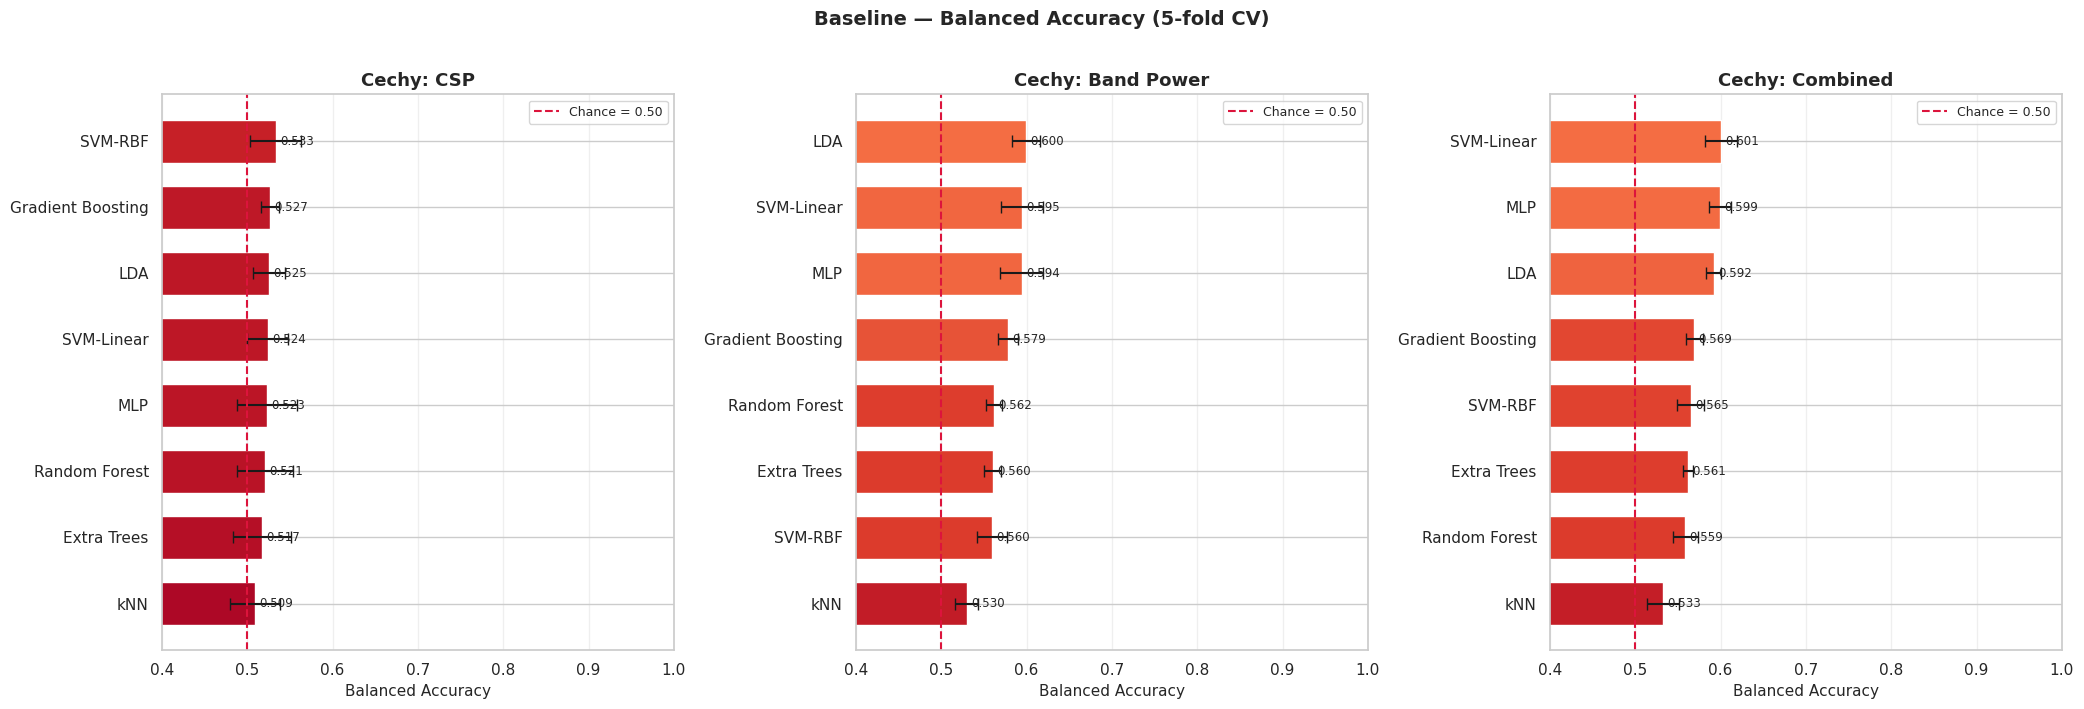


🏆 Top-5 pojedynczych modeli:
     model   features     mean      std
SVM-Linear   Combined 0.600700 0.018571
       LDA Band Power 0.599840 0.016473
       MLP   Combined 0.599161 0.012536
SVM-Linear Band Power 0.594604 0.024196
       MLP Band Power 0.594145 0.024827


In [7]:
df_base = pd.DataFrame([
    {'model':    k.split(' | ')[0],
     'features': k.split(' | ')[1],
     'mean':     v.mean(),
     'std':      v.std()}
    for k, v in baseline_results.items()
])

chance = 1.0 / n_classes
fig, axes = plt.subplots(1, 3, figsize=(21, 7), sharey=False)

for ax, feat_name in zip(axes, ['CSP', 'Band Power', 'Combined']):
    sub = df_base[df_base['features'] == feat_name].sort_values('mean')
    norm = (sub['mean'] - chance) / (1 - chance)  # normalize to [0,1] above chance
    colors = plt.cm.RdYlGn(norm.clip(0, 1).values)

    bars = ax.barh(sub['model'], sub['mean'], xerr=sub['std'],
                   color=colors, edgecolor='white', height=0.65, capsize=4)
    ax.axvline(chance, color='crimson', linestyle='--', linewidth=1.5,
               label=f'Chance = {chance:.2f}')
    ax.set_xlim(max(0, chance - 0.1), 1.0)
    ax.set_title(f'Cechy: {feat_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Balanced Accuracy', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)

    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_width() + 0.005,
                bar.get_y() + bar.get_height() / 2,
                f'{row["mean"]:.3f}', va='center', fontsize=8.5)

plt.suptitle('Baseline — Balanced Accuracy (5-fold CV)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

top5 = df_base.nlargest(5, 'mean')[['model', 'features', 'mean', 'std']]
print("\n🏆 Top-5 pojedynczych modeli:")
print(top5.to_string(index=False))

## Krok 8 — Voting Ensemble

Automatycznie wybiera top-5 modeli z wyników baseline na cechach Combined i klonuje świeże instancje do ensemble. Buduje dwa warianty: `voting_soft` sumuje prawdopodobieństwa klas ważone accuracy z baseline, `voting_hard` stosuje zwykłe głosowanie większościowe — oba są oceniane tym samym 5-fold CV.

In [8]:
N_TOP = 5
top_rows = (df_base[df_base['features'] == 'Combined']
            .nlargest(N_TOP, 'mean'))
top_names   = top_rows['model'].tolist()
top_weights = top_rows['mean'].tolist()

print(f"Top-{N_TOP} modele wybrane do ensemble:")
for n, w in zip(top_names, top_weights):
    print(f"  {n:<22s}  acc={w:.3f}")

top_estimators = [
    (name.replace(' ', '_').replace('-', '_'), clone(BASE_MODELS[name]))
    for name in top_names
]

voting_soft = VotingClassifier(
    estimators=top_estimators,
    voting='soft',
    weights=top_weights,
    n_jobs=-1,
)

voting_hard = VotingClassifier(
    estimators=top_estimators,
    voting='hard',
    n_jobs=-1,
)

ensemble_results = {}
print("\nEwaluacja Voting Ensemble (subject-based CV)...")
for name, clf in [('Voting Soft (weighted)', voting_soft),
                  ('Voting Hard',            voting_hard)]:
    scores = cross_val_score(clf, X_raw, y, cv=CV,
                             groups=groups, scoring=SCORING)
    ensemble_results[name] = scores
    print(f"  {name:<28s}  {scores.mean():.3f} ± {scores.std():.3f}")


Top-5 modele wybrane do ensemble:
  SVM-Linear              acc=0.601
  MLP                     acc=0.599
  LDA                     acc=0.592
  Gradient Boosting       acc=0.569
  SVM-RBF                 acc=0.565

Ewaluacja Voting Ensemble (subject-based CV)...
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: 

## Krok 9 — Stacking Ensemble

Buduje `StackingClassifier` na tych samych top-5 modelach co voting: każdy base learner generuje out-of-fold predykcje prawdopodobieństw za pomocą wbudowanego 5-fold CV, a Logistic Regression jako meta-learner uczy się optymalnych wag dla każdego modelu na podstawie tych predykcji. Wynik oceniany jest zewnętrznym 5-fold CV.

In [9]:
# Internal CV for stacking must also be subject-aware.
# StackingClassifier doesn't pass groups to its internal cv splitter,
# so we use a custom splitter that captures groups at construction time.

class SubjectGroupCV:
    """CV splitter that always splits by subject groups.
    Wraps StratifiedGroupKFold but stores groups internally,
    because StackingClassifier doesn't forward groups to its cv."""
    def __init__(self, groups, n_splits=5):
        self.groups = groups
        self.n_splits = n_splits

    def split(self, X, y=None, groups=None):
        sgkf = StratifiedGroupKFold(n_splits=self.n_splits)
        return sgkf.split(X, y, groups=self.groups)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

stacking = StackingClassifier(
    estimators=top_estimators,
    final_estimator=Pipeline([
        ('scaler', StandardScaler()),
        ('meta',   LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ]),
    cv=SubjectGroupCV(groups, n_splits=5),  # subject-aware internal CV!
    passthrough=False,
    n_jobs=-1,
)

print("Ewaluacja Stacking Ensemble (subject-based CV, wewnątrz i na zewnątrz)...")
scores = cross_val_score(stacking, X_raw, y, cv=CV,
                         groups=groups, scoring=SCORING)
ensemble_results['Stacking (LR meta)'] = scores
print(f"  Stacking (LR meta):          {scores.mean():.3f} ± {scores.std():.3f}")


Ewaluacja Stacking Ensemble (subject-based CV, wewnątrz i na zewnątrz)...
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
Computing rank from data with rank=None
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Using tolerance 0.0025 (2.2e-16 eps * 64 dim * 1.8e+11  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
    Estimated rank (data): 64
    d

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/opt/conda/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py", line 463, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/joblib/parallel.py", line 598, in __call__
    return [func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/joblib/parall

## Krok 10 — Finalne porównanie: baseline vs ensemble

Zbiera wyniki wszystkich baseline'ów (tylko na cechach Combined, żeby porównanie było uczciwe) i obu metod ensemble w jeden DataFrame, a następnie rysuje wspólny wykres słupkowy z kolorami niebieski/czerwony dla baseline/ensemble. Na końcu drukuje nazwę i wynik najlepszego modelu spośród wszystkich.

In [ ]:
all_results = {}

# Baseline: tylko Combined (fair comparison z ensemble)
for k, v in baseline_results.items():
    if k.endswith('| Combined'):
        all_results[k.replace(' | Combined', '')] = v

# Ensemble
all_results.update(ensemble_results)

df_all = pd.DataFrame([
    {'name': k, 'mean': v.mean(), 'std': v.std(),
     'type': 'Ensemble' if k.startswith(('Voting', 'Stacking')) else 'Baseline'}
    for k, v in all_results.items()
]).sort_values('mean', ascending=True)

palette = {'Baseline': '#5B9BD5', 'Ensemble': '#E85D5D'}
colors  = df_all['type'].map(palette).values

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_all['name'], df_all['mean'], xerr=df_all['std'],
               color=colors, edgecolor='white', height=0.7, capsize=4)

ax.axvline(chance, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Poziom losowy ({chance:.2f})')
ax.set_xlim(max(0, chance - 0.05), 1.0)
ax.set_xlabel('Balanced Accuracy (5-fold StratifiedGroupKFold)', fontsize=12)
ax.set_title('Baseline vs Ensemble — Subject-Independent CV (leakage-free)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in palette.items()]
legend_handles.append(plt.Line2D([0], [0], color='crimson',
                                 linestyle='--', label='Chance level'))
ax.legend(handles=legend_handles, fontsize=10, loc='lower right')

for bar, (_, row) in zip(bars, df_all.iterrows()):
    ax.text(bar.get_width() + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{row["mean"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

best_name = df_all.loc[df_all['mean'].idxmax(), 'name']
best_acc  = df_all['mean'].max()
print(f"\n🥇 Najlepszy model: {best_name}  →  {best_acc:.3f} balanced accuracy")


## Krok 11 — Macierze pomyłek

Automatycznie wyłania najlepszy baseline i najlepszy ensemble z poprzedniego kroku, a następnie generuje dla każdego z nich predykcje out-of-fold przez `cross_val_predict` (bez ryzyka przeuczenia). Rysuje dwie macierze pomyłek obok siebie i drukuje pełny classification report dla najlepszego ensemble.

In [ ]:
# Best baseline on Combined features
best_baseline_name = (df_all[df_all['type'] == 'Baseline']
                      .sort_values('mean', ascending=False)
                      ['name'].iloc[0])

# Best ensemble
best_ensemble_name = (df_all[df_all['type'] == 'Ensemble']
                      .sort_values('mean', ascending=False)
                      ['name'].iloc[0])

print(f"Best baseline:  {best_baseline_name}")
print(f"Best ensemble:  {best_ensemble_name}")

model_lookup = {
    name: clone(BASE_MODELS[name])
    for name in BASE_MODELS
}
model_lookup['Voting Soft (weighted)'] = clone(voting_soft)
model_lookup['Voting Hard']            = clone(voting_hard)
model_lookup['Stacking (LR meta)']     = clone(stacking)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name in zip(axes, [best_baseline_name, best_ensemble_name]):
    clf    = model_lookup[name]
    y_pred = cross_val_predict(clf, X_raw, y, cv=CV, groups=groups)
    acc    = balanced_accuracy_score(y, y_pred)
    cm     = confusion_matrix(y, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nBal. Acc = {acc:.3f}', fontsize=11, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')

plt.suptitle('Confusion matrices — out-of-fold (subject-independent CV)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nClassification Report: {best_ensemble_name}")
clf    = model_lookup[best_ensemble_name]
y_pred = cross_val_predict(clf, X_raw, y, cv=CV, groups=groups)
print(classification_report(y, y_pred, target_names=le.classes_))


## Krok 12 (Bonus) — Ważność cech w najlepszym modelu drzewiastym

Jeśli Random Forest lub Extra Trees znalazł się wśród wyników, trenuje go na pełnym zbiorze `X_combined` i odczytuje `feature_importances_` z wytrenowanego drzewa. Rysuje słupkowy wykres top-20 najważniejszych cech z rozróżnieniem kolorystycznym między komponentami CSP (czerwony) a kanałami Band Power (niebieski).

In [ ]:
tree_candidate = next(
    (n for n in df_all.sort_values('mean', ascending=False)['name']
     if n in ('Random Forest', 'Extra Trees')),
    None,
)

if tree_candidate is None:
    print("No tree-based model in results — skip this cell.")
else:
    tree_clf = clone(BASE_MODELS[tree_candidate])
    tree_clf.fit(X_raw, y)  # full fit for feature importance (not for eval!)
    
    # Get importances from the classifier step
    importances = tree_clf.named_steps['clf'].feature_importances_
    
    # Feature names: CSP components + BandPower channels
    csp_feat_names = [f'CSP_{i+1}' for i in range(N_CSP)]
    bp_feat_names  = (
        [f'Mu_ch{i+1}'   for i in range(X_raw.shape[1])] +
        [f'Beta_ch{i+1}' for i in range(X_raw.shape[1])]
    )
    feat_names = csp_feat_names + bp_feat_names
    
    # Safety check: match feature count
    if len(importances) != len(feat_names):
        print(f"Warning: {len(importances)} importances vs {len(feat_names)} names")
        feat_names = [f'feat_{i}' for i in range(len(importances))]

    top_n = min(20, len(importances))
    idx   = np.argsort(importances)[::-1][:top_n]

    fig, ax = plt.subplots(figsize=(12, 6))
    colors_feat = ['#E85D5D' if 'CSP' in feat_names[i] else '#5B9BD5' for i in idx]
    ax.bar(range(top_n), importances[idx], color=colors_feat, edgecolor='white')
    ax.set_xticks(range(top_n))
    ax.set_xticklabels([feat_names[i] for i in idx], rotation=45, ha='right')
    ax.set_ylabel('Feature Importance (Gini)', fontsize=11)
    ax.set_title(f'Top-{top_n} features — {tree_candidate}',
                 fontsize=13, fontweight='bold')

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#E85D5D', label='CSP'),
                       Patch(color='#5B9BD5', label='Band Power')],
              fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
